# 02 · Training Neural Networks — Code

Part A: implement Batch GD, SGD, and Mini-Batch SGD from scratch in NumPy and compare their loss curves.
Part B: reproduce the comparison in PyTorch using `DataLoader` + a learning-rate scheduler.

# Part A — NumPy From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def bce(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [2]:
class Net:
    """Same architecture as lesson 01, but train() now supports batch/sgd/mini-batch."""
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1, lr=0.5):
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros((1, output_dim))
        self.lr = lr

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        dz2 = (self.a2 - y) / n
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

def train(net, X, y, epochs, batch_size, verbose_every=None):
    """batch_size = len(X) -> Batch GD | batch_size = 1 -> SGD | else -> Mini-Batch SGD"""
    n = X.shape[0]
    loss_history = []
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        X_shuffled, y_shuffled = X[perm], y[perm]
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch, y_batch = X_shuffled[start:end], y_shuffled[start:end]
            y_pred = net.forward(X_batch)
            net.backward(X_batch, y_batch)
        # record loss on FULL training set at the end of each epoch, for fair comparison
        full_pred = net.forward(X)
        loss_history.append(bce(y, full_pred))
    return loss_history

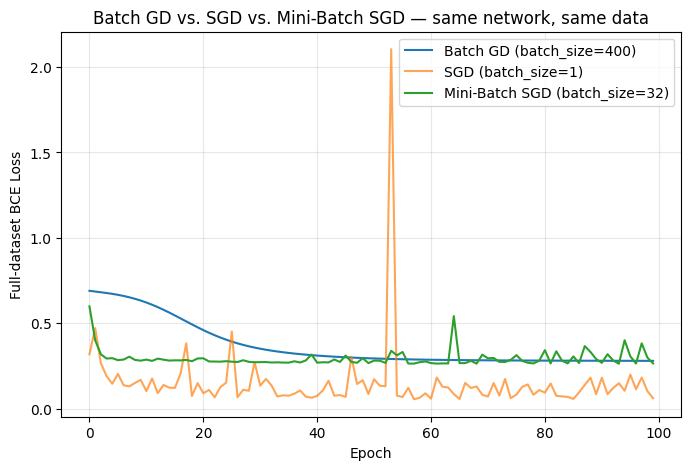

Notice: SGD's curve is visibly noisier (each update sees only 1 example).
Mini-batch is the smooth middle ground everyone uses in practice.


In [3]:
np.random.seed(0)
net_batch = Net(lr=0.5)
loss_batch = train(net_batch, X_train, y_train, epochs=100, batch_size=len(X_train))  # Batch GD

np.random.seed(0)
net_sgd = Net(lr=0.5)
loss_sgd = train(net_sgd, X_train, y_train, epochs=100, batch_size=1)                 # pure SGD

np.random.seed(0)
net_mb = Net(lr=0.5)
loss_mb = train(net_mb, X_train, y_train, epochs=100, batch_size=32)                  # Mini-batch SGD

plt.figure(figsize=(8, 5))
plt.plot(loss_batch, label=f'Batch GD (batch_size={len(X_train)})')
plt.plot(loss_sgd, label='SGD (batch_size=1)', alpha=0.7)
plt.plot(loss_mb, label='Mini-Batch SGD (batch_size=32)')
plt.xlabel("Epoch"); plt.ylabel("Full-dataset BCE Loss")
plt.title("Batch GD vs. SGD vs. Mini-Batch SGD — same network, same data")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Notice: SGD's curve is visibly noisier (each update sees only 1 example).")
print("Mini-batch is the smooth middle ground everyone uses in practice.")

## Epoch / Batch / Iteration in numbers

In [4]:
n_train = len(X_train)
batch_size = 32
iterations_per_epoch = int(np.ceil(n_train / batch_size))
epochs = 20
total_iterations = iterations_per_epoch * epochs

print(f"Training examples: {n_train}")
print(f"Batch size: {batch_size}")
print(f"Iterations per epoch: {iterations_per_epoch}")
print(f"Epochs: {epochs}")
print(f"Total weight updates (iterations): {total_iterations}")

Training examples: 400
Batch size: 32
Iterations per epoch: 13
Epochs: 20
Total weight updates (iterations): 260


## Learning-Rate Scheduling (from scratch)

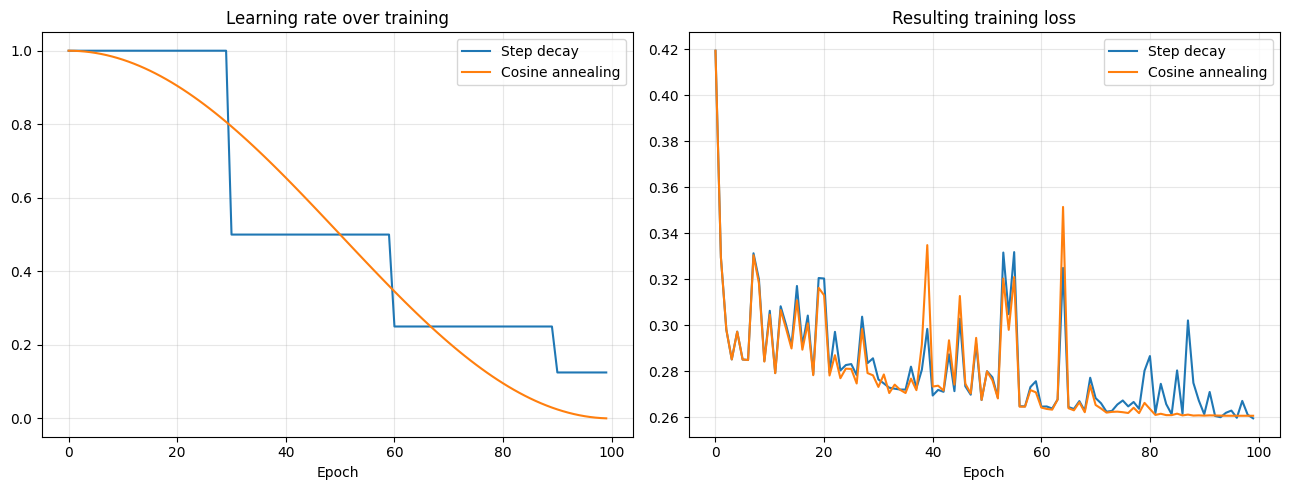

In [5]:
def train_with_schedule(net, X, y, epochs, batch_size, schedule_fn):
    n = X.shape[0]
    loss_history, lr_history = [], []
    for epoch in range(epochs):
        net.lr = schedule_fn(epoch)  # <-- update learning rate before this epoch's updates
        lr_history.append(net.lr)
        perm = np.random.permutation(n)
        X_shuffled, y_shuffled = X[perm], y[perm]
        for start in range(0, n, batch_size):
            end = start + batch_size
            net.forward(X_shuffled[start:end])
            net.backward(X_shuffled[start:end], y_shuffled[start:end])
        loss_history.append(bce(y, net.forward(X)))
    return loss_history, lr_history

def step_decay(epoch, initial_lr=1.0, drop_factor=0.5, drop_every=30):
    return initial_lr * (drop_factor ** (epoch // drop_every))

def cosine_annealing(epoch, initial_lr=1.0, total_epochs=100):
    return initial_lr * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))

np.random.seed(0)
net_step = Net(lr=1.0)
loss_step, lr_step = train_with_schedule(net_step, X_train, y_train, 100, 32,
                                          lambda e: step_decay(e))

np.random.seed(0)
net_cos = Net(lr=1.0)
loss_cos, lr_cos = train_with_schedule(net_cos, X_train, y_train, 100, 32,
                                        lambda e: cosine_annealing(e))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(lr_step, label='Step decay')
axes[0].plot(lr_cos, label='Cosine annealing')
axes[0].set_title("Learning rate over training"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(loss_step, label='Step decay')
axes[1].plot(loss_cos, label='Cosine annealing')
axes[1].set_title("Resulting training loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part B — PyTorch Equivalent

`DataLoader` handles batching/shuffling; `torch.optim.lr_scheduler` handles the schedule.

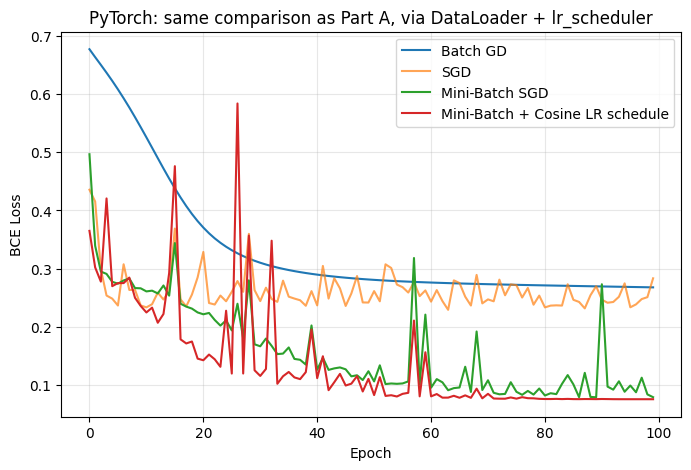

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

class TorchNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc2(self.relu(self.fc1(x))))

def run_training(batch_size, epochs=100, lr=0.5, use_scheduler=False):
    torch.manual_seed(0)
    model = TorchNet()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) if use_scheduler else None

    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)  # <-- handles batching + shuffling

    loss_history = []
    for epoch in range(epochs):
        for X_batch, y_batch in loader:            # <-- one "iteration" per batch
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()                        # <-- update learning rate once per epoch
        with torch.no_grad():
            loss_history.append(criterion(model(X_train_t), y_train_t).item())
    return loss_history

loss_batch_t = run_training(batch_size=len(X_train))   # Batch GD
loss_sgd_t   = run_training(batch_size=1)               # SGD
loss_mb_t    = run_training(batch_size=32)               # Mini-batch SGD
loss_sched_t = run_training(batch_size=32, lr=1.0, use_scheduler=True)  # Mini-batch + cosine schedule

plt.figure(figsize=(8, 5))
plt.plot(loss_batch_t, label='Batch GD')
plt.plot(loss_sgd_t, label='SGD', alpha=0.7)
plt.plot(loss_mb_t, label='Mini-Batch SGD')
plt.plot(loss_sched_t, label='Mini-Batch + Cosine LR schedule')
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("PyTorch: same comparison as Part A, via DataLoader + lr_scheduler")
plt.legend(); plt.grid(alpha=0.3)
plt.show()